In [1]:
import numpy as np
import pandas as pd
import loompy
import scanpy as sc
import scvelo as scv

/home/bt392/miniconda3/envs/env_rna/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:363: NumbaWarning: The TBB threading layer requires TBB version 2019.5 or later i.e., TBB_INTERFACE_VERSION >= 11005. Found TBB_INTERFACE_VERSION = 9106. The TBB threading layer is disabled.
  warnings.warn(problem)


In [2]:
# open list of velocyto output files
rabbit_list = open("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/mouse_list.txt", 'r')
#content = rabbit_list.read()
content_list = rabbit_list.readlines()
# add .loom to end of string
content_list = [s.replace('\n', '.loom') for s in content_list]
# add locaion to start of names
location = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/'
content_list = [location + s for s in content_list]

# Out file
out_file = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/looms_concat.loom'
out_final = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/chim_velocity_final.h5ad'

# meta
metadata = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/big_meta_mapping.tab'
collection_meta = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/chim_collection_meta.csv"

# integrated h5 for pca & umap
big_adata = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas_analysis.h5"


In [4]:
content_list

['/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAA5.loom',
 '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAB5.loom',
 '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAC5.loom',
 '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAD5.loom',
 '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAE5.loom',
 '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/velocity/looms/SLX19260_Mixl1_SIGAF5.loom']

In [5]:
# Concatenate looms
loompy.combine(content_list, out_file , key="Accession")

### Adding metadata

In [3]:
# open concatenated looms
adata = sc.read(out_file)

KeyboardInterrupt: 

In [ ]:
meta = pd.read_csv(metadata, '\t')
collection = pd.read_csv(collection_meta, ',')

In [ ]:
# Merged based on Sample and barcode
adata.obs['barcode'] = [s.split('_')[2] for s in adata.obs.index]
adata.obs['ID'] = [s.split(':')[0] for s in adata.obs['barcode']]
adata.obs['barcode'] = [s.split(':')[1] for s in adata.obs['barcode']]
adata.obs['barcode'] = [s.replace('x', '') for s in adata.obs['barcode']]
adata.obs = adata.obs[['barcode', 'ID']]

# convert ID to sample
collection = collection[['sample','ID']]
collection['sample'] = ['mixl_' + s for s in collection['sample'].apply(str)]
adata.obs = adata.obs.merge(collection, on=['ID'])

In [8]:
adata.obs

,barcode,ID,sample,cell,stage,sequencing.batch,stripped,doublet,theiler,doub.density,...,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell
index,,,,,,,,,,,,,,,,,,,,,
chim_cell_1,AAACCCAAGCATAGGC,SIGAA5,mixl_1,chim_cell_1,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139332.0,E8.25,Paraxial mesoderm,atlas_cell_74754
chim_cell_2,AAACCCAAGGGACTGT,SIGAA5,mixl_1,chim_cell_2,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139333.0,E8.5,Erythroid3,atlas_cell_134274
chim_cell_3,AAACCCACAAGCAATA,SIGAA5,mixl_1,chim_cell_3,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139334.0,E8.25,Pharyngeal mesoderm,atlas_cell_93757
chim_cell_4,AAACCCACATCTTCGC,SIGAA5,mixl_1,chim_cell_4,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139335.0,E8.25,Forebrain/Midbrain/Hindbrain,atlas_cell_92424
chim_cell_5,AAACCCAGTATCTCTT,SIGAA5,mixl_1,chim_cell_5,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139336.0,E8.5,Forebrain/Midbrain/Hindbrain,atlas_cell_38846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chim_cell_43819,TTTGGTTTCGGACCAC,SIGAF5,mixl_6,chim_cell_43819,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183150.0,E8.0,Intermediate mesoderm,atlas_cell_121130
chim_cell_43821,TTTGTTGGTCACTTAG,SIGAF5,mixl_6,chim_cell_43821,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183152.0,E8.25,Paraxial mesoderm,atlas_cell_63302
chim_cell_43822,TTTGTTGGTCCGACGT,SIGAF5,mixl_6,chim_cell_43822,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183153.0,E8.5,Neural crest,atlas_cell_102526


In [ ]:
# convert ID to sample
collection = collection[['sample','ID']]
collection['sample'] = ['mixl_' + s for s in collection['sample'].apply(str)]

## collection metadata contains mistake = problem!

In [155]:
## Error in the metadata supplied by MLNT!! -> Unclear which cells are actually 
adata.obs['sample'] = adata.obs['ID'] 
adata.obs['sample'] = [s.replace('SIGAA5', 'mixl_1') for s in adata.obs['sample']]
adata.obs['sample'] = [s.replace('SIGAB5', 'mixl_2') for s in adata.obs['sample']]
adata.obs['sample'] = [s.replace('SIGAC5', 'mixl_3') for s in adata.obs['sample']]
adata.obs['sample'] = [s.replace('SIGAD5', 'mixl_4') for s in adata.obs['sample']]
adata.obs['sample'] = [s.replace('SIGAE5', 'mixl_5') for s in adata.obs['sample']]
adata.obs['sample'] = [s.replace('SIGAF5', 'mixl_6') for s in adata.obs['sample']]

In [166]:
# Merge adata.obs with metadata
adata.obs = adata.obs.merge(meta, on=['sample', 'barcode'], how = 'left')

AnnData expects .obs.index to contain strings, but your first indices are: Int64Index([0, 1], dtype='int64'), …


In [186]:
adata.write(out_final)

... storing 'barcode' as categorical
... storing 'ID' as categorical
... storing 'sample' as categorical
... storing 'cell' as categorical
... storing 'stage' as categorical
... storing 'stripped' as categorical
... storing 'doublet' as categorical
... storing 'theiler' as categorical
... storing 'celltype' as categorical
... storing 'colour' as categorical
... storing 'haem_subclust' as categorical
... storing 'endo_trajectoryName' as categorical
... storing 'endo_gutCluster' as categorical
... storing 'tdTom' as categorical
... storing 'stage.mapped' as categorical
... storing 'celltype.mapped' as categorical
... storing 'closest.cell' as categorical
... storing 'Chromosome' as categorical
... storing 'Strand' as categorical


In [211]:
adata = sc.read(out_final)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [216]:
adata = adata[adata.obs['cell'] != 'nan']

In [218]:
adata.write(out_final)

In [220]:
# Add PCs and UMAP from analysed object
big_adata = sc.read(big_adata)
# Extract chim cells
big_adata = big_adata[big_adata.obs['tdTom'] != 'nan']

# make cells match
adata.obs.index = adata.obs['cell']
reorder = adata.obs.sort_values(by='weight').index
adata = adata[reorder]
adata.obs.index = adata.obs['cell']

# transfer data
adata.obsm['X_pca'] = big_adata.obsm['X_pca']
adata.obsm['X_umap'] = big_adata.obsm['X_umap']
adata.uns['celltype.mapped_colors'] = big_adata.uns['celltype_colors']

In [296]:
adata.var

,Accession,Chromosome,End,Start,Strand
Xkr4,ENSMUSG00000051951,1,3671498,3205901,-
Gm37381,ENSMUSG00000102343,1,3986215,3905739,-
Rp1,ENSMUSG00000025900,1,4409241,3999557,-
Sox17,ENSMUSG00000025902,1,4497354,4490931,-
Gm37323,ENSMUSG00000104328,1,4586252,4583129,-
...,...,...,...,...,...
Gm28672,ENSMUSG00000100492,Y,89225296,89222067,+
Gm28670,ENSMUSG00000099982,Y,89394761,89391528,+
Gm29504,ENSMUSG00000100533,Y,90277501,90275224,+
Gm20837,ENSMUSG00000096178,Y,90433263,90401248,+


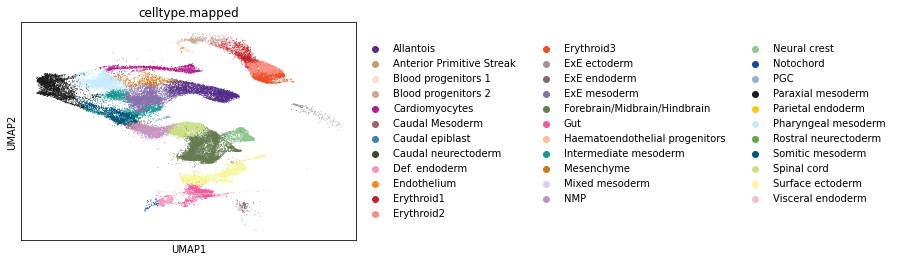

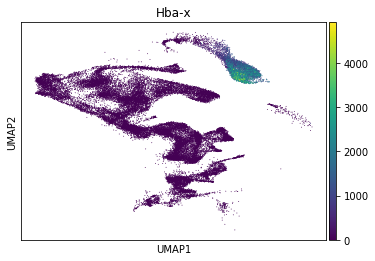

In [299]:
sc.pl.umap(adata, color='celltype.mapped')
sc.pl.umap(adata, color='Hba-x')

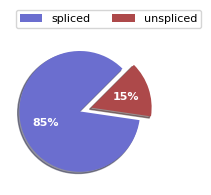

In [290]:
scv.pl.proportions(adata)

In [305]:
adata.obs.index = adata.obs.index.rename('index')

In [307]:
adata.write(out_final)

In [3]:
adata = sc.read(out_final)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [7]:
adata.obs

,barcode,ID,sample,cell,stage,sequencing.batch,stripped,doublet,theiler,doub.density,...,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell
index,,,,,,,,,,,,,,,,,,,,,
chim_cell_1,AAACCCAAGCATAGGC,SIGAA5,mixl_1,chim_cell_1,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139332.0,E8.25,Paraxial mesoderm,atlas_cell_74754
chim_cell_2,AAACCCAAGGGACTGT,SIGAA5,mixl_1,chim_cell_2,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139333.0,E8.5,Erythroid3,atlas_cell_134274
chim_cell_3,AAACCCACAAGCAATA,SIGAA5,mixl_1,chim_cell_3,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139334.0,E8.25,Pharyngeal mesoderm,atlas_cell_93757
chim_cell_4,AAACCCACATCTTCGC,SIGAA5,mixl_1,chim_cell_4,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139335.0,E8.25,Forebrain/Midbrain/Hindbrain,atlas_cell_92424
chim_cell_5,AAACCCAGTATCTCTT,SIGAA5,mixl_1,chim_cell_5,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,pos,139336.0,E8.5,Forebrain/Midbrain/Hindbrain,atlas_cell_38846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chim_cell_43819,TTTGGTTTCGGACCAC,SIGAF5,mixl_6,chim_cell_43819,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183150.0,E8.0,Intermediate mesoderm,atlas_cell_121130
chim_cell_43821,TTTGTTGGTCACTTAG,SIGAF5,mixl_6,chim_cell_43821,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183152.0,E8.25,Paraxial mesoderm,atlas_cell_63302
chim_cell_43822,TTTGTTGGTCCGACGT,SIGAF5,mixl_6,chim_cell_43822,E8.5,1.0,False,False,nan,NaN,...,NaN,NaN,NaN,NaN,nan,neg,183153.0,E8.5,Neural crest,atlas_cell_102526


In [4]:
test = adata.obs[['sample', 'ID']]

In [10]:
test.reset_index(drop=True).drop_duplicates()

,sample,ID
0,mixl_1,SIGAA5
6756,mixl_2,SIGAB5
15697,mixl_3,SIGAC5
19661,mixl_4,SIGAD5
22829,mixl_5,SIGAE5
30216,mixl_6,SIGAF5
